SUPPORT VECTOR REGRESSION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Local environment setup
from pathlib import Path

In [3]:
from pathlib import Path

DATASET_PATH = Path("household_power_consumption.csv")
if not DATASET_PATH.exists() and (Path("FRANCE_DATASET") / "household_power_consumption.csv").exists():
    DATASET_PATH = Path("FRANCE_DATASET") / "household_power_consumption.csv"

file_path = DATASET_PATH

df = pd.read_csv(
    file_path,
    sep=';',
    header=None
)

print("Original dataset shape:", df.shape)

df.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_6112\1616290886.py:9: DtypeWarning: Columns (0: 2, 1: 3, 2: 4, 3: 5, 4: 6, 5: 7, 6: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Original dataset shape: (2075260, 9)


,0,1,2,3,4,5,6,7,8
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [4]:
df.columns = [
    'Date',
    'Time',
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.000
2,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.000
3,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.000
4,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.000


In [5]:
# Convert numerical columns
numeric_columns = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Combine Date and Time
df['Datetime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

# Remove invalid/missing rows
df = df.dropna()

# Sort according to time
df = df.sort_values('Datetime').reset_index(drop=True)

print("Rows after cleaning:", len(df))

df.head()

Rows after cleaning: 2049280


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [6]:
df = df.iloc[:20000].copy()

print("Records used for SVR:", len(df))

Records used for SVR: 20000


In [7]:
energy = df[['Global_active_power']].values

print("Energy data shape:", energy.shape)
print(energy[:10])

Energy data shape: (20000, 1)
[[4.216]
 [5.36 ]
 [5.374]
 [5.388]
 [3.666]
 [3.52 ]
 [3.702]
 [3.7  ]
 [3.668]
 [3.662]]


In [8]:
scaler = MinMaxScaler()

energy_scaled = scaler.fit_transform(energy)

print(energy_scaled[:10])

[[0.44998881]
 [0.57798165]
 [0.579548  ]
 [0.58111434]
 [0.38845379]
 [0.37211904]
 [0.39248154]
 [0.39225778]
 [0.38867756]
 [0.38800627]]


In [9]:
time_steps = 30

X = []
y = []

for i in range(time_steps, len(energy_scaled)):
    X.append(energy_scaled[i-time_steps:i, 0])
    y.append(energy_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19970, 30)
y shape: (19970,)


In [10]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15976, 30)
Testing data: (3994, 30)


In [11]:
svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.01
)

print("SVR model created.")

SVR model created.


In [12]:
print("Training SVR...")

svr_model.fit(X_train, y_train)

print("SVR training completed!")

Training SVR...


SVR training completed!


In [13]:
df = df.iloc[:10000].copy()

In [14]:
predictions = svr_model.predict(X_test)

print("Prediction completed!")
print("Number of predictions:", len(predictions))

Prediction completed!
Number of predictions: 3994


In [15]:
predictions_actual = scaler.inverse_transform(
    predictions.reshape(-1, 1)
)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("Actual values:", y_test_actual[:5].flatten())
print("Predicted values:", predictions_actual[:5].flatten())

Actual values: [2.568 2.566 2.546 2.542 2.95 ]
Predicted values: [2.74335286 2.52481768 2.66177707 2.69280632 2.62792842]


In [16]:
mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)

MAE: 0.26195296068923857


In [17]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

print("RMSE:", rmse)

RMSE: 0.5780823944383512


In [18]:
r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("R² Score:", r2)

R² Score: 0.8501502507040078


In [19]:
print("================================")
print("       SVR MODEL PERFORMANCE")
print("================================")

print("MAE  :", mae)
print("RMSE :", rmse)
print("R²   :", r2)

       SVR MODEL PERFORMANCE
MAE  : 0.26195296068923857
RMSE : 0.5780823944383512
R²   : 0.8501502507040078


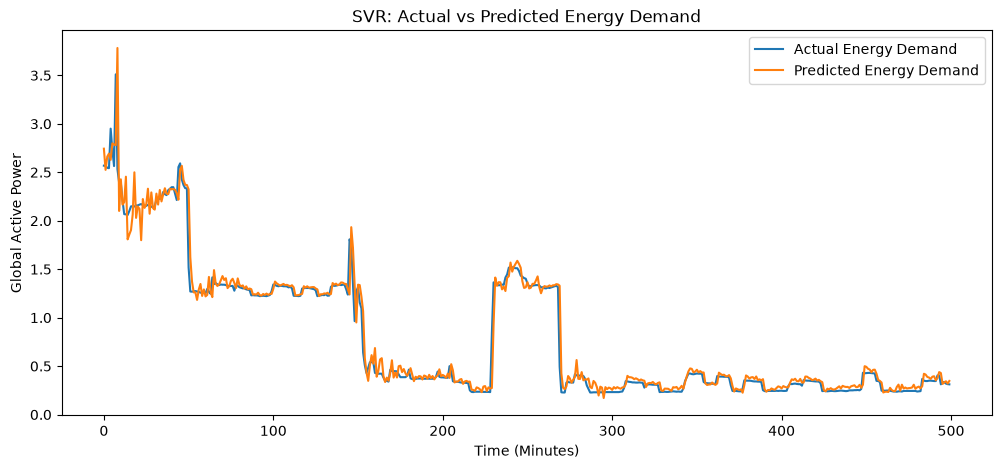

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual[:500],
    label='Actual Energy Demand'
)

plt.plot(
    predictions_actual[:500],
    label='Predicted Energy Demand'
)

plt.xlabel('Time (Minutes)')
plt.ylabel('Global Active Power')

plt.title('SVR: Actual vs Predicted Energy Demand')

plt.legend()

plt.show()

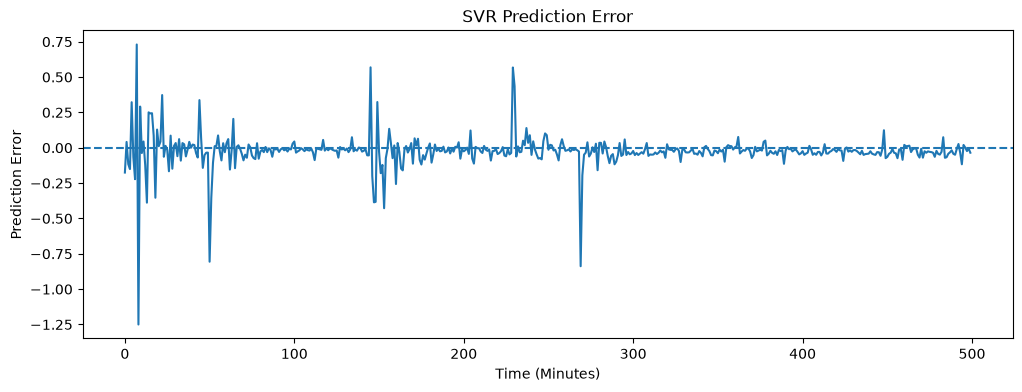

In [21]:
errors = y_test_actual.flatten() - predictions_actual.flatten()

plt.figure(figsize=(12, 4))

plt.plot(errors[:500])

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Time (Minutes)')
plt.ylabel('Prediction Error')

plt.title('SVR Prediction Error')

plt.show()

In [22]:
results = pd.DataFrame({
    'Actual_Energy_Demand': y_test_actual.flatten(),
    'Predicted_Energy_Demand': predictions_actual.flatten()
})

results.head(10)

,Actual_Energy_Demand,Predicted_Energy_Demand
0,2.568,2.743353
1,2.566,2.524818
2,2.546,2.661777
3,2.542,2.692806
4,2.950,2.627928
5,2.732,2.798461
6,2.564,2.786275
7,3.510,2.779697
8,2.532,3.781997
9,2.392,2.100834


In [23]:
from pathlib import Path

OUTPUT_DIR = Path("SVR_Output")
if not OUTPUT_DIR.exists() and (Path("FRANCE_DATASET") / "SVR_Output").exists():
    OUTPUT_DIR = Path("FRANCE_DATASET") / "SVR_Output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREDICTION_PATH = OUTPUT_DIR / "svr_predictions.csv"

results.to_csv(
    PREDICTION_PATH,
    index=False
)

print(f"SVR predictions saved successfully to {PREDICTION_PATH}!")

SVR predictions saved successfully to SVR_Output\svr_predictions.csv!


In [24]:
import joblib

MODEL_PATH = OUTPUT_DIR / "smart_grid_svr_model.pkl"

joblib.dump(
    svr_model,
    MODEL_PATH
)

print(f"SVR model saved successfully to {MODEL_PATH}!")

SVR model saved successfully to SVR_Output\smart_grid_svr_model.pkl!


In [25]:
print("======================================")
print("       SMART GRID ENERGY FORECAST")
print("              SVR MODEL")
print("======================================")

print("Dataset Size       :", len(df))
print("Time Steps         :", time_steps)
print("Training Samples   :", len(X_train))
print("Testing Samples    :", len(X_test))
print("--------------------------------------")
print("MAE                :", mae)
print("RMSE               :", rmse)
print("R² Score           :", r2)
print("--------------------------------------")
print("Model: Support Vector Regression")
print("Kernel: RBF")
print("======================================")

       SMART GRID ENERGY FORECAST
              SVR MODEL
Dataset Size       : 10000
Time Steps         : 30
Training Samples   : 15976
Testing Samples    : 3994
--------------------------------------
MAE                : 0.26195296068923857
RMSE               : 0.5780823944383512
R² Score           : 0.8501502507040078
--------------------------------------
Model: Support Vector Regression
Kernel: RBF
